From the [Muon Tutorials for Single-cell RNA-seq and ATAC-seq integration](https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/1-Gene-Expression-Processing.html)

In [13]:
# Single-cell packages
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import anndata as ad
import pysam
import scvi  # SCANVI reference-based cell type transfer

from pathlib import Path

# General helpful packages for data analysis and visualization
import pandas as pd
import scanpy as sc
import seaborn as sns
from muon import atac as ac  # the module containing function for scATAC data processing

# Setting figure parameters
sc.settings.verbosity = 0

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")
PROJECT_DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")

ORGANISM_CODE = "mm10"
CELL_TYPE = "mouse_liver"
DATASET_NAME = "mouse_liver_10x_raw"
SAMPLE_NAME = "liver_sample"
RAW_DATA_DIR = PROJECT_DATA_DIR / "RAW_DATA" / DATASET_NAME
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed" / CELL_TYPE

def default_tss_bed(species):
    """Prefer <species>_gene_tss.bed -- that is what the existing samples were built with."""
    annotation_dir = PROJECT_DIR / "data" / "genome_data" / "genome_annotation" / species
    preferred = annotation_dir / f"{species}_gene_tss.bed"
    return preferred if preferred.exists() else annotation_dir / "gene_tss.bed"

tss_path = default_tss_bed(ORGANISM_CODE)

# Set to None if you have 10X files instead of count files
rna_count_file = None
atac_count_file = None

# Set to None if you have matrix, features, barcode files instead of an h5 file
raw_h5_file = RAW_DATA_DIR / "GSE288579_filtered_feature_bc_matrix.h5"

# If you want to keep all TFs to maximize overlap with the ground truth files, pass in a ground truth file path here.
tf_list_file = None

# If you are running with 10X, replace None with the path to your indexed fragment file (for nucleosome signal filtering)
frag_path = None

SAMPLE_DATA_DIR = RAW_DATA_DIR / SAMPLE_NAME
SAMPLE_PROCESSED_DATA_DIR = PROCESSED_DATA_DIR / SAMPLE_NAME

if not SAMPLE_PROCESSED_DATA_DIR.exists():
    SAMPLE_PROCESSED_DATA_DIR.mkdir(parents=True)

print(f"Loading data for sample {SAMPLE_NAME} from {RAW_DATA_DIR}...")
# print all files in the data directory
for file in SAMPLE_DATA_DIR.glob("*"):
    print(f"  - {file.name}")
    file_end = file.name.split("_")[-1]
    print(file_end)
    if file_end.endswith("barcodes.tsv.gz"):
        file.rename(SAMPLE_DATA_DIR / f"barcodes.tsv.gz")
    elif file_end.endswith("features.tsv.gz"):
        file.rename(SAMPLE_DATA_DIR / f"features.tsv.gz")
    elif file_end.endswith("matrix.mtx.gz"):
        file.rename(SAMPLE_DATA_DIR / f"matrix.mtx.gz")
    elif file_end.endswith("fragments.tsv.gz"):
        file.rename(SAMPLE_DATA_DIR / f"fragments.tsv.gz")
    elif file_end.endswith("fragments.tsv.gz.tbi"):
        file.rename(SAMPLE_DATA_DIR / f"fragments.tsv.gz.tbi")
        

Loading data for sample liver_sample from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA/mouse_liver_10x_raw...


In [10]:
# def get_threshold(setting_name):
#     setting_value = sample_filtering_settings[setting_name].values[0]
#     print(f"{setting_name}: {setting_value}")
    
#     return setting_value

# filtering_setting_df = pd.read_csv(PROJECT_DIR / "data" / "qc_filtering_settings.tsv", sep="\t")
# sample_filtering_settings = filtering_setting_df[filtering_setting_df["Sample"] == SAMPLE_NAME]    

# # ----- RNA QC thresholds -----
# MIN_CELLS_PER_GENE = get_threshold("Min Cells per Gene")

# MIN_GENES_PER_CELL = get_threshold("Min Genes per Cell")
# MAX_GENES_PER_CELL = get_threshold("Max Genes per Cell")

# MIN_TOTAL_COUNTS = get_threshold("Min Total Counts")
# MAX_TOTAL_COUNTS = get_threshold("Max Total Counts")
# MAX_PCT_COUNTS_MT = get_threshold("Max Pct MT")
# MAX_PCT_COUNTS_RIBO = get_threshold("Max Pct Ribo")

# # ----- ATAC QC thresholds -----
# MIN_CELLS_PER_PEAK = get_threshold("Min Cells per Peak")

# MIN_PEAKS_PER_CELL = get_threshold("Min Peaks per Cell")
# MAX_PEAKS_PER_CELL = get_threshold("Max Peaks per Cell")

# MIN_TOTAL_PEAK_COUNTS = get_threshold("Min Total Peak Counts")
# MAX_TOTAL_PEAK_COUNTS = get_threshold("Max Total Peak Counts")

## Load in the Raw Data

In [3]:
def normalize_peak_format(peak_id: str) -> str:
    """
    Normalize peak format from chrN-start-end or chrN:start:end to chrN:start-end.
    Handles both formats as input and always outputs chrN:start-end.
    """
    if not isinstance(peak_id, str):
        return peak_id
    
    # Try to parse chr-start-end format (with dashes)
    parts = peak_id.split('-')
    if len(parts) >= 3:
        # Assume format is chr-start-end where chr might have dashes
        # Work backwards: the last two parts are start and end
        try:
            end = int(parts[-1])
            start = int(parts[-2])
            chrom = '-'.join(parts[:-2])  # Everything before the last two parts
            return f"{chrom}:{start}-{end}"
        except (ValueError, IndexError):
            pass
    
    # Already in chr:start-end format or some other format, return as-is
    return peak_id

def construct_from_gene_by_cell_matrices(rna_count_file, atac_count_file):
    assert rna_count_file.exists(), "rna count file does not exist"
    assert atac_count_file.exists(), "atac count file does not exist"
    
    rna_count_matrix = pd.read_csv(rna_count_file, header=0, index_col=0)
    atac_count_matrix = pd.read_csv(atac_count_file, header=0, index_col=0)
    
    rna_matrix = rna_count_matrix.T.values
    rna_metadata_df = pd.DataFrame(index=rna_count_matrix.columns)
    rna_features_df = pd.DataFrame(index=rna_count_matrix.index)
    
    atac_count_matrix.index = atac_count_matrix.index.map(normalize_peak_format)

    atac_matrix = atac_count_matrix.T.values
    atac_metadata_df = pd.DataFrame(index=atac_count_matrix.columns)
    atac_features_df = pd.DataFrame(index=atac_count_matrix.index)
    
    adata_rna = ad.AnnData(X=rna_matrix, obs=rna_metadata_df, var=rna_features_df)
    adata_rna.var["feature_types"] = "Gene Expression"
    adata_rna.var["gene_ids"] = adata_rna.var_names

    adata_atac = ad.AnnData(X=atac_matrix, obs=atac_metadata_df, var=atac_features_df)
    adata_atac.var["feature_types"] = "Peaks"
    adata_atac.var["gene_ids"] = adata_atac.var_names

    mdata = mu.MuData({'rna': adata_rna, 'atac': adata_atac})

    return mdata

def filter_to_human(mdata):
    """
    Filter a barnyard MuData object to hg38 ATAC peaks only,
    then strip the 'hg38.' prefix from peak IDs.
    """
    if "hg38" in mdata["atac"].var_names[0]:
        # annotate species from interval
        mdata["atac"].var["species"] = (
            mdata["atac"].var["interval"].str.split(".", n=1).str[0]
        )

        # keep only hg38 peaks
        hg38_mask = mdata["atac"].var["species"] == "hg38"
        mdata.mod["atac"] = mdata["atac"][:, hg38_mask].copy()

        # strip prefix from identifiers
        mdata.mod["atac"].var_names = (
            mdata.mod["atac"].var_names.str.replace(r"^hg38\.", "", regex=True)
        )
        mdata.mod["atac"].var["gene_ids"] = (
            mdata.mod["atac"].var["gene_ids"].str.replace(r"^hg38\.", "", regex=True)
        )
        mdata.mod["atac"].var["interval"] = (
            mdata.mod["atac"].var["interval"].str.replace(r"^hg38\.", "", regex=True)
        )
        mdata = mu.MuData(mdata.mod)

    return mdata

Build the mdata object, either from raw 10X genomic data, a 10x h5 file, or from a counts file. If you build from counts files, you won't be able to run the ATAC-seq QC filtering steps that require fragment files.

In [4]:
if rna_count_file is not None and atac_count_file is not None:
    rna_count_filepath = SAMPLE_DATA_DIR / rna_count_file
    atac_count_filepath = SAMPLE_DATA_DIR / atac_count_file
    
    mdata = construct_from_gene_by_cell_matrices(rna_count_filepath, atac_count_filepath)
    print("Constructed MuData object from count files.")
elif raw_h5_file is not None:
    mdata = mu.read_10x_h5(raw_h5_file)
else:
    mdata = mu.read_10x_mtx(SAMPLE_DATA_DIR)
        
mdata.var_names_make_unique()
display(mdata)

mdata.write(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA/mouse_liver_10x_raw/GSE288579_filtered_feature_bc_matrix.h5


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/sit

MuData object with n_obs × n_vars = 24936 × 181678
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	24936 x 32285
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	24936 x 149393
      var:	'gene_ids', 'feature_types', 'genome', 'interval'

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [13]:
# print(mdata["rna"].var["gene_ids"][:5])
# print("\n", mdata["atac"].var["gene_ids"][:5])
# print("\n", mdata["rna"].var["feature_types"][:5])
# print("\n", mdata["atac"].var["feature_types"][:5])
# print("\n", mdata.var["feature_types"][:5])
# print("\n", mdata.var["gene_ids"][:5])
# print("\n", mdata["rna"].X[:5, :5])

## Assign each mouse an observation

In [35]:
mdata.obs["donor"] = "mouse_" + mdata.obs_names.str.rsplit("-", n=1).str[1]

# RNA

In [38]:
rna = mdata.mod['rna']
rna

AnnData object with n_obs × n_vars = 24936 × 32285
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Preprocessing

### QC

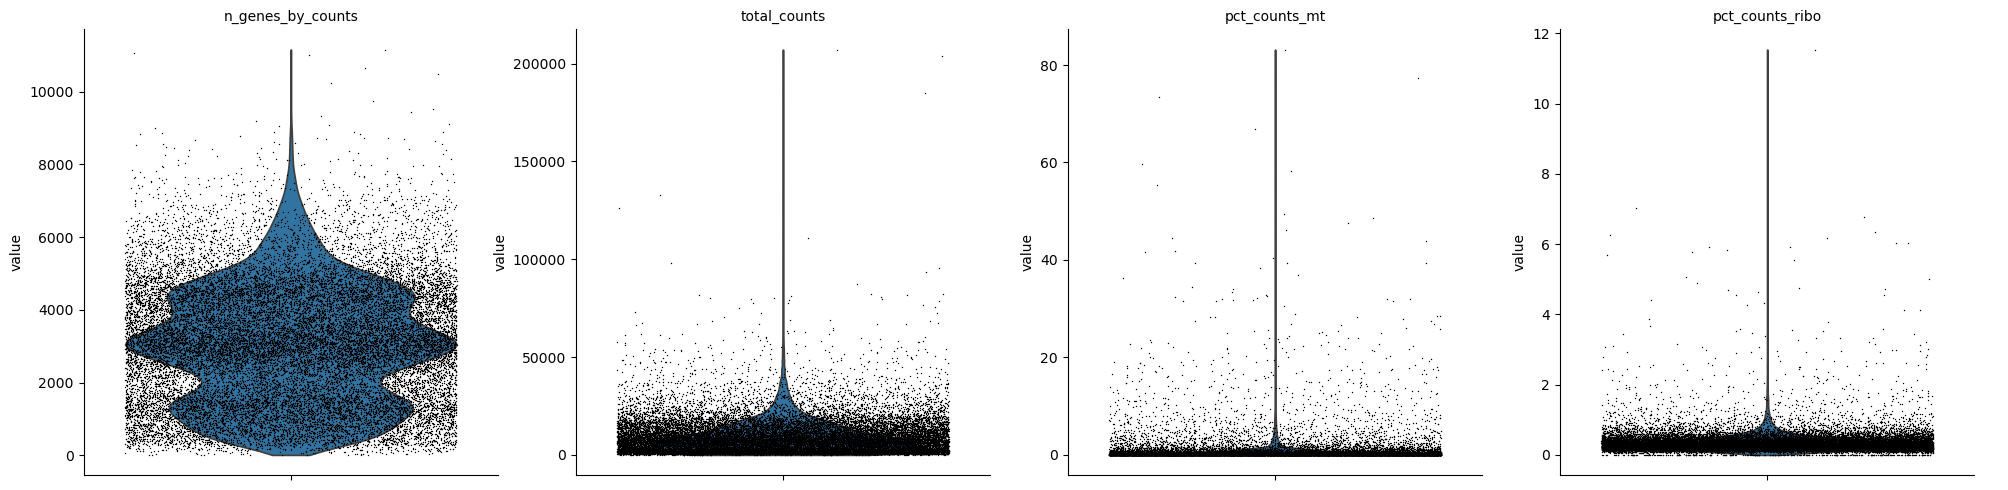

In [39]:
rna.var['mt'] = rna.var_names.str.upper().str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
rna.var['ribo'] = rna.var_names.str.upper().str.startswith('RPL') | rna.var_names.str.upper().str.startswith('RPS')  # annotate the group of ribosomal genes as 'ribo'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt', 'ribo'], percent_top=[20], log1p=True, inplace=True)

sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
             jitter=0.4, multi_panel=True)

Filter genes and cells based on the thresholds above

In [40]:
from scipy.stats import median_abs_deviation

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

# Filter out cells that are out of 5 MADs
rna.obs["outlier"] = (
    is_outlier(rna, "log1p_total_counts", 5)
    | is_outlier(rna, "log1p_n_genes_by_counts", 5)
    | is_outlier(rna, "pct_counts_in_top_20_genes", 5)
)
rna.obs.outlier.value_counts()

outlier
False    23854
True      1082
Name: count, dtype: int64

In [41]:
rna.obs["mt_outlier"] = is_outlier(rna, "pct_counts_mt", 5) | (
    rna.obs["pct_counts_mt"] > 25
)
rna.obs.mt_outlier.value_counts()

mt_outlier
False    20441
True      4495
Name: count, dtype: int64

In [42]:
print(f"Total number of cells: {rna.n_obs}")
rna_filtered = rna[(~rna.obs.outlier) & (~rna.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {rna_filtered.n_obs}")

Total number of cells: 24936
Number of cells after filtering of low quality cells: 20277


In [43]:
print(f"Total number of genes: {rna_filtered.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(rna_filtered, min_cells=20)
print(f"Number of genes after cell filter: {rna_filtered.n_vars}")

Total number of genes: 32285
Number of genes after cell filter: 18960


Detect and remove doublets

In [11]:
sc.pp.scrublet(rna_filtered)

# Filter out doublets
rna_filtered = rna_filtered[~rna_filtered.obs["predicted_doublet"], :]
print(f"Number of genes after cell filter: {rna_filtered.n_vars}")

Number of genes after cell filter: 18960


Check to see how the data looks after filtering.

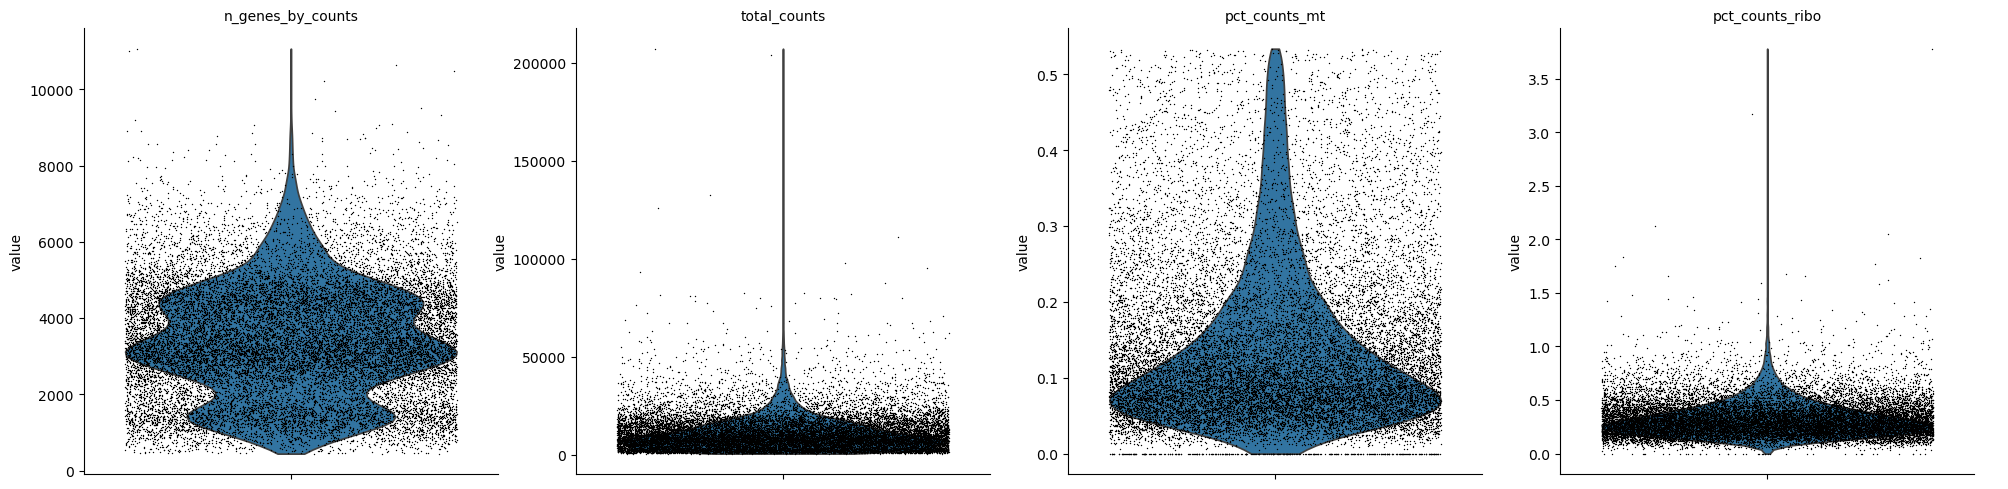

In [44]:
sc.pl.violin(rna_filtered, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
             jitter=0.4, multi_panel=True)

In [45]:
rna_filtered.layers["counts"] = rna_filtered.X.copy()

### Normalization

In [46]:
sc.pp.normalize_total(rna_filtered, target_sum=1e4)
sc.pp.log1p(rna_filtered)

### Feature Selection

We will label highly variable genes that we'll use for downstream analysis.

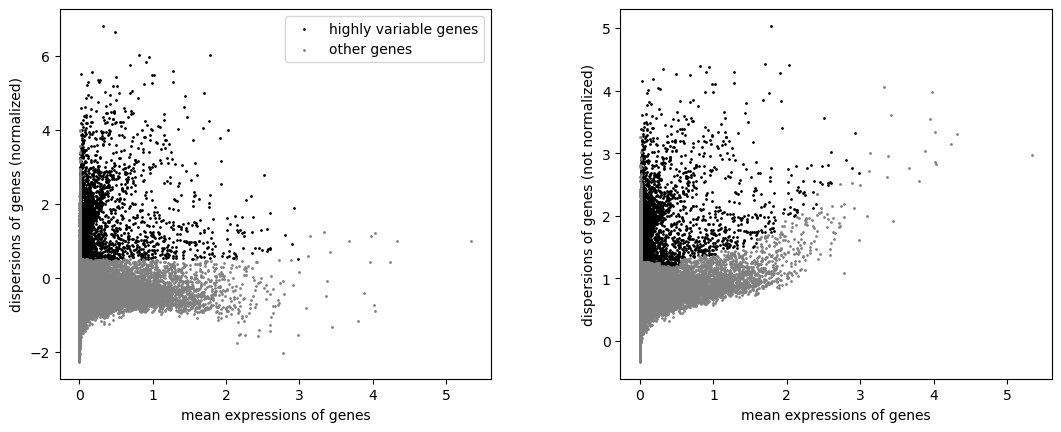

In [47]:
sc.pp.highly_variable_genes(rna_filtered)
sc.pl.highly_variable_genes(rna_filtered)

In [26]:
# keep_genes = rna_filtered.var["highly_variable"]
# rna_filtered = rna_filtered[:, keep_genes]
# np.sum(rna_filtered.var.highly_variable)

### Scaling

We'll save log-normalized counts in a `.raw` slot, then scale the log-normalized counts to zero mean and unit variance

['Xkr4', 'Sox17', 'Gm37587']


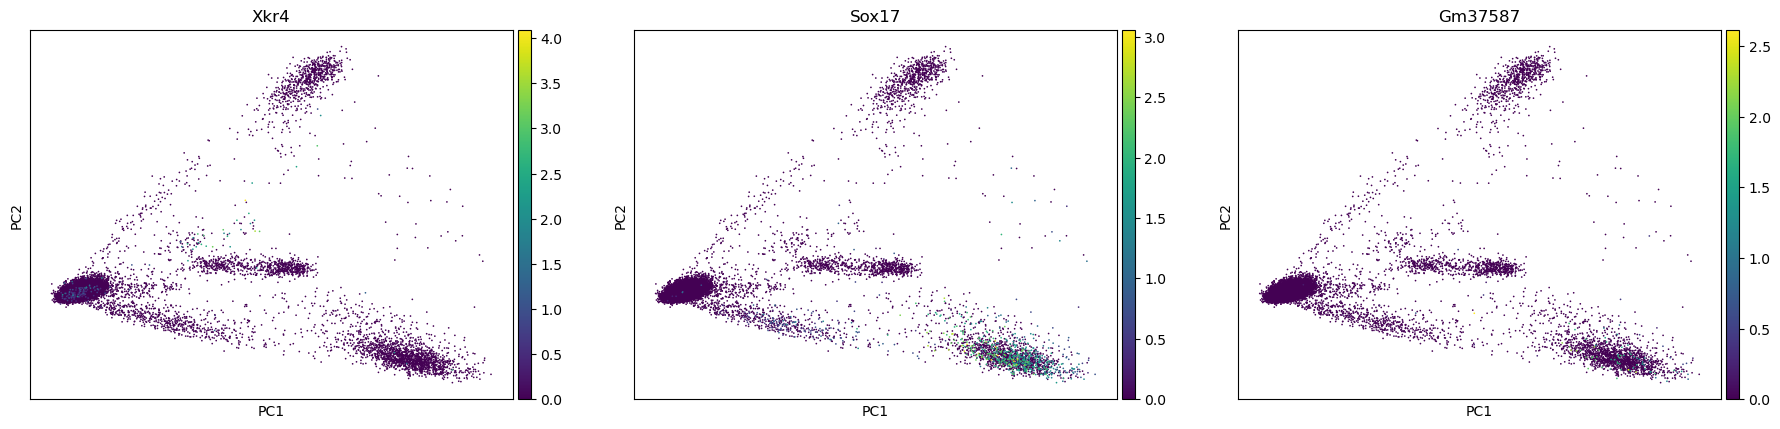

In [48]:
sc.tl.pca(rna_filtered, svd_solver='arpack')

first_three_hvg_genes = rna_filtered.var[rna_filtered.var.highly_variable].index[:3].to_list()
print(first_three_hvg_genes)

sc.pl.pca(rna_filtered, color=first_three_hvg_genes)

In [53]:
rna_filtered.obs["donor"] = "mouse_" + rna_filtered.obs_names.str.rsplit("-", n=1).str[1]

## Harmony integration

In [55]:
import harmonypy
import numpy as np

ho = harmonypy.run_harmony(
    rna_filtered.obsm["X_pca"].astype(np.float64),
    rna_filtered.obs,
    "donor",
)

Z = np.asarray(ho.Z_corr)
if Z.shape[0] != rna_filtered.n_obs:   # handles either orientation
    Z = Z.T

rna_filtered.obsm["X_pca_harmony"] = Z

2026-09-15 16:22:38,839 - harmonypy - INFO - Running Harmony
2026-09-15 16:22:38,839 - harmonypy - INFO -   Parameters:
2026-09-15 16:22:38,839 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-15 16:22:38,840 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-15 16:22:38,840 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-15 16:22:38,840 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-15 16:22:38,840 - harmonypy - INFO -     nclust: 100
2026-09-15 16:22:38,840 - harmonypy - INFO -     block_size: 0.05
2026-09-15 16:22:38,841 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-15 16:22:38,841 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-09-15 16:22:38,841 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-15 16:22:38,841 - harmonypy - INFO -     verbose: True
2026-09-15 16:22:38,842 - harmonypy - INFO -     random_state: 0
2026-09-15 16:22:38,842 - harmonypy - INFO -   Data: 50 PCs × 20277 cells
2026-09-15 16:22:38,842 - harmonypy - 

## Analysis

### PCA and Neighborhood Graph

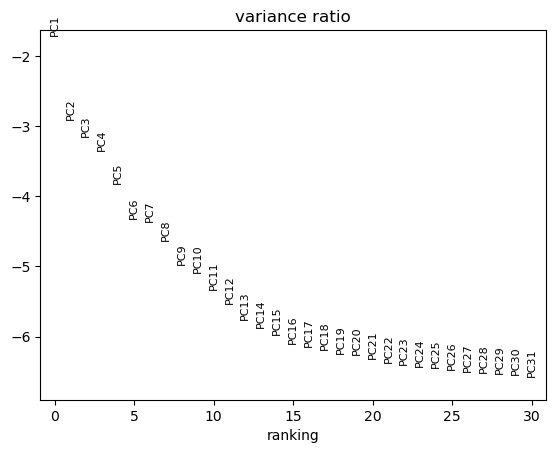

In [56]:
sc.pl.pca_variance_ratio(rna_filtered, log=True)

### Neighbors

In [57]:
sc.pp.pca(rna_filtered, svd_solver="arpack", mask_var="highly_variable")

In [58]:
sc.tl.tsne(rna_filtered, use_rep="X_pca")

### Non-linear dimensionality reduction and clustering

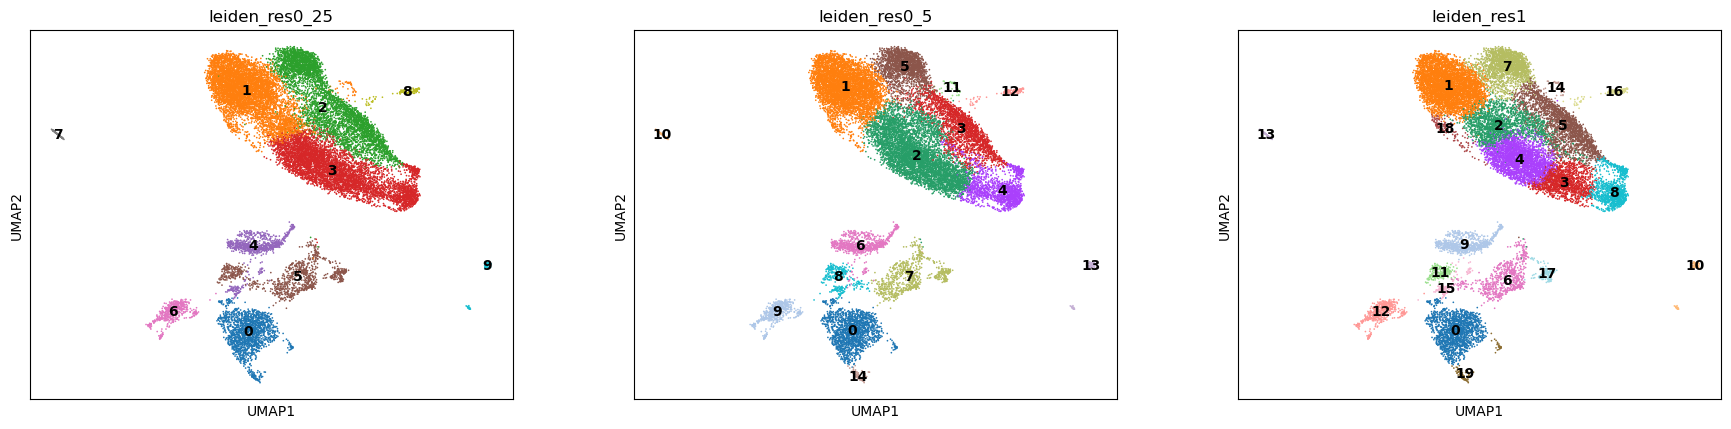

In [59]:
sc.pp.neighbors(rna_filtered, use_rep="X_pca_harmony")
sc.tl.umap(rna_filtered, spread=1., min_dist=.5, random_state=11)

sc.tl.leiden(
    rna_filtered, key_added="leiden_res0_25", resolution=0.25, flavor="igraph", n_iterations=2
)
sc.tl.leiden(
    rna_filtered, key_added="leiden_res0_5", resolution=0.5, flavor="igraph", n_iterations=2
)
sc.tl.leiden(
    rna_filtered, key_added="leiden_res1", resolution=1.0, flavor="igraph", n_iterations=2
)

sc.pl.umap(
    rna_filtered,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
)

In [60]:
rna_filtered

AnnData object with n_obs × n_vars = 20277 × 18960
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'donor', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'tsne', 'neighbors', 'umap', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res0_25_colors', 'leiden_res0_5_colors', 'leiden_res1_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## Cell Type Mapping

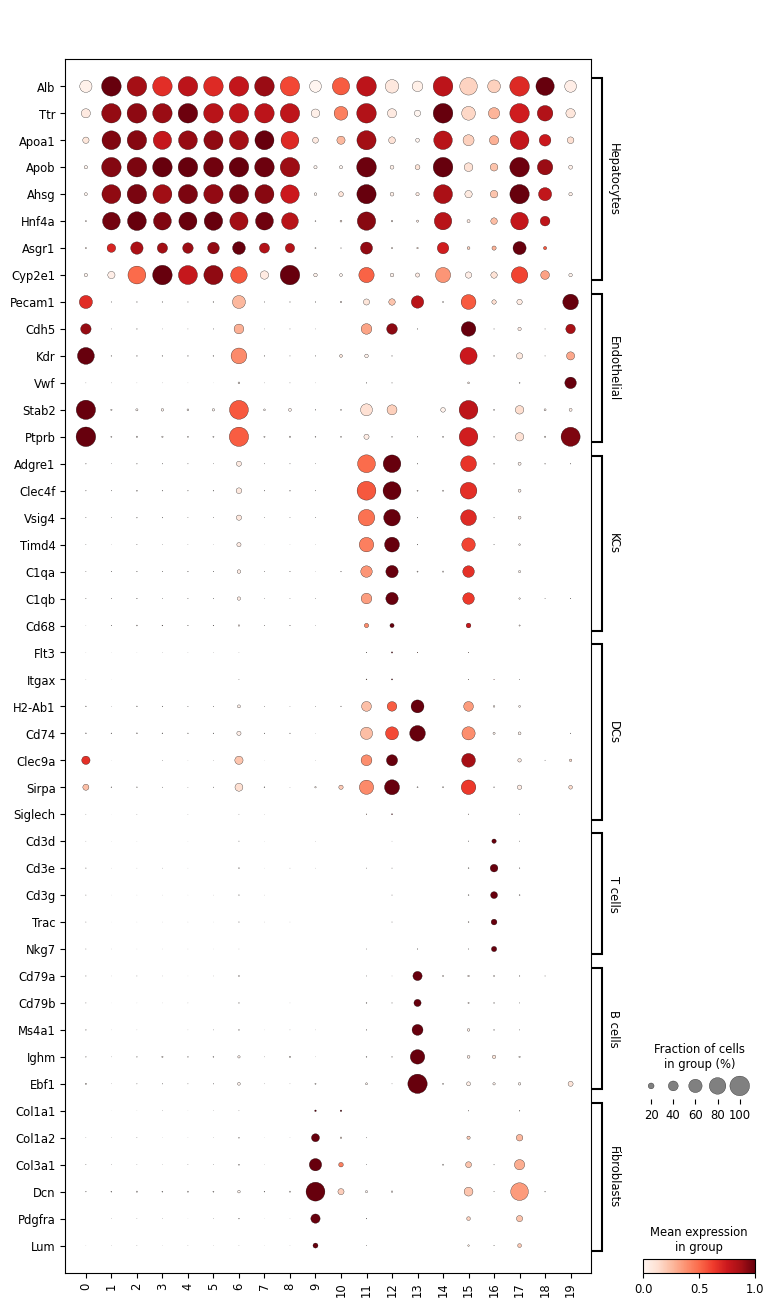

In [93]:
marker_dict = {
    "Hepatocytes":   ["Alb", "Ttr", "Apoa1", "Apob", "Ahsg", "Hnf4a", "Asgr1", "Cyp2e1"],
    "Endothelial":   ["Pecam1", "Cdh5", "Kdr", "Vwf", "Stab2", "Ptprb"],
    "KCs": ["Adgre1", "Clec4f", "Vsig4", "Timd4", "C1qa", "C1qb", "Cd68"],
    "DCs":     ["Flt3", "Itgax", "H2-Ab1", "Cd74", "Xcr1", "Clec9a", "Sirpa", "Siglech"],
    "T cells":       ["Cd3d", "Cd3e", "Cd3g", "Trac", "Cd8a", "Nkg7"],
    "B cells":       ["Cd79a", "Cd79b", "Ms4a1", "Ighm", "Ebf1"],
    "Fibroblasts":   ["Col1a1", "Col1a2", "Col3a1", "Dcn", "Pdgfra", "Lum"],
}

# Keep only genes present in the RNA object
marker_dict_present = {
    group: [g for g in genes if g in rna_filtered.var_names]
    for group, genes in marker_dict.items()
}

# Remove empty groups
marker_dict_present = {
    group: genes
    for group, genes in marker_dict_present.items()
    if len(genes) > 0
}

sc.pl.dotplot(
    rna_filtered,
    var_names=marker_dict_present,
    groupby="leiden_res1",
    standard_scale="var",
    dendrogram=False,
    swap_axes=True
)

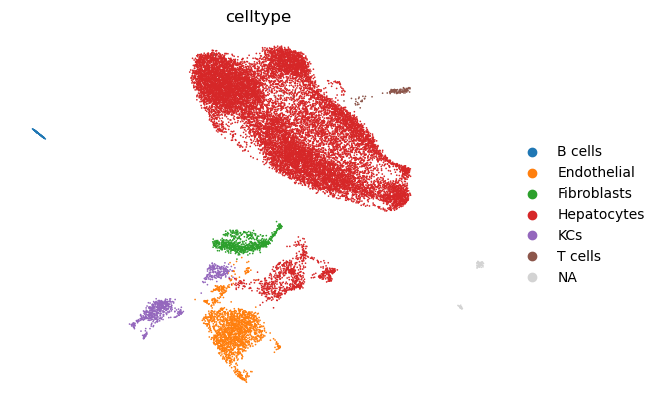

In [113]:
celltype_map = {
    "Hepatocytes":  [1, 2, 3, 4, 5, 6, 7, 8, 14, 17, 18],
    "Endothelial":  [0, 15, 19],
    "KCs":          [11, 12],
    "DCs":          [],
    "T cells":      [16],
    "B cells":      [13],
    "Fibroblasts":  [9],
}

cluster_to_celltype = {
    str(c): ct for ct, clusters in celltype_map.items() for c in clusters
}

rna_filtered.obs["celltype"] = (
    rna_filtered.obs["leiden_res1"]
    .astype(str)
    .map(cluster_to_celltype)
    .astype("category")
)

# Plot UMAP with cell type labels
sc.pl.umap(
    rna_filtered,
    color=["celltype"],
    vmax="p99",
    frameon=False,
)

## Saving progress to disk

In [98]:
mu.write(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu/rna"), rna_filtered)
print(f"Saved RNA data to {SAMPLE_PROCESSED_DATA_DIR / f'{SAMPLE_NAME}.h5mu/rna'}")

Saved RNA data to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/liver_sample/liver_sample.h5mu/rna


---

# ATAC

In [70]:
atac = mdata.mod['atac']
atac  # an AnnData object

AnnData object with n_obs × n_vars = 24936 × 149393
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

## Preprocessing

### QC

Filter out cells with too few peaks and peaks detected in too few cells.

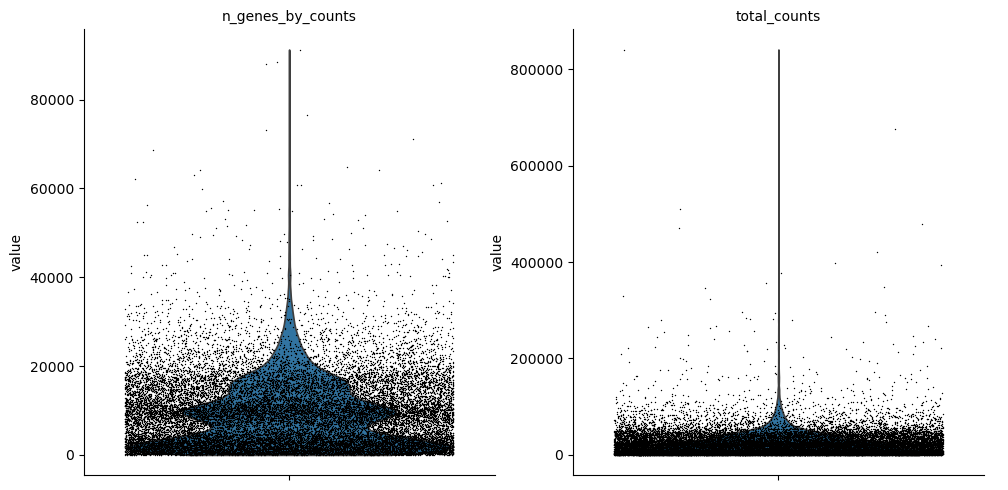

In [71]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(atac, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)

In [72]:
# # Remove peaks that are not detected in at least MIN_CELLS_PER_PEAK cells
# mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)

# # Remove cells where the number of accessible peaks is outside of the range [MIN_PEAKS_PER_CELL, MAX_PEAKS_PER_CELL]
# mu.pp.filter_obs(atac, 'n_genes_by_counts', lambda x: (x >= 0) & (x <= 30000))

# # # Remove cells whose peak count sum is outside of the range [MIN_TOTAL_PEAK_COUNTS, MAX_TOTAL_PEAK_COUNTS]
# mu.pp.filter_obs(atac, 'total_counts', lambda x: (x >= 0) & (x <= 100000))

# Filter out cells that are out of 5 MADs
atac.obs["outlier"] = (
    is_outlier(atac, "n_genes_by_counts", 5)
    | is_outlier(atac, "total_counts", 5)
)
# Remove peaks that are not detected in at least MIN_CELLS_PER_PEAK cells
mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)

atac.obs.outlier.value_counts()

outlier
False    24304
True       632
Name: count, dtype: int64

In [73]:
print(f"Total number of cells: {atac.n_obs}")
atac_filtered = atac[(~atac.obs.outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {atac_filtered.n_obs}")

Total number of cells: 24936


Number of cells after filtering of low quality cells: 24304


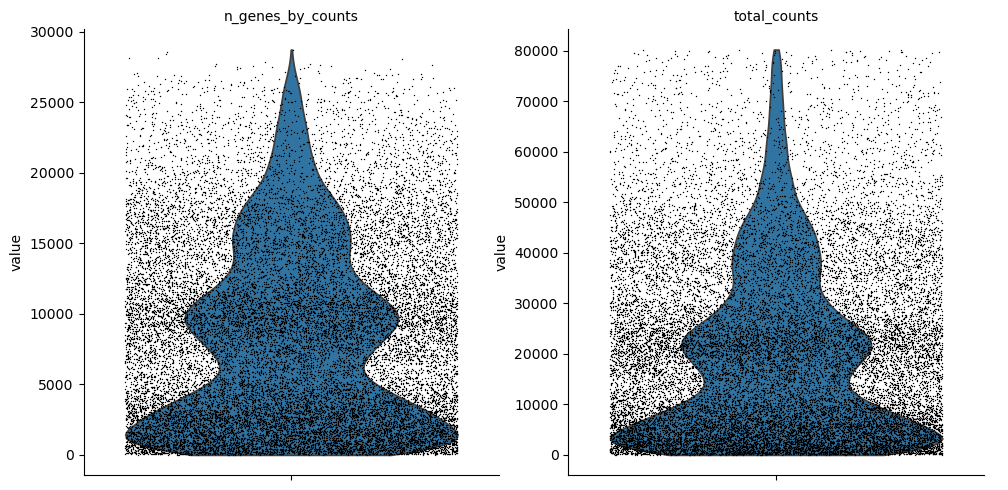

In [74]:
sc.pl.violin(atac_filtered, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)

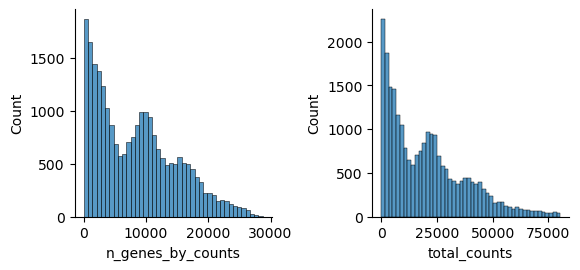

In [75]:
mu.pl.histogram(atac_filtered, ['n_genes_by_counts', 'total_counts'])

### ATAC-specific QC
There are a few expectations about how ATAC-seq data looks like as noted in the [hitchhiker’s guide to ATAC-seq data analysis](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-020-1929-3#citeas) for instance


#### Nucleosome Signal

Fragment size distribution typically reflects nucleosome binding pattern showing enrichment around values corresponding to fragments bound to a single nucleosome (between 147 bp and 294 bp) as well as nucleosome-free fragments (shorter than 147 bp).

In [76]:
if frag_path is not None:
    index_file = str(frag_path) + ".tbi"

    if Path(index_file).exists():
        print("Found index:", index_file)

    else:
        # Index the fragment file
        print("Index file not found. Creating index file...")
        pysam.tabix_index(
            str(frag_path),
            preset="bed",
            force=True
        )
        index_file = str(frag_path) + ".tbi"

    # Create the index file for the fragments
    tbx = pysam.TabixFile(str(frag_path))
    print(tbx.contigs[:20])

    # register the fragment file with the ATAC AnnData
    ac.tl.locate_fragments(atac_filtered, fragments=str(frag_path))

    print(atac_filtered.uns["files"])
    print(atac_filtered.uns["files"]["fragments"])
    # optional grouping column if you want one
    atac_filtered.obs["NS"] = 1

    def find_nonempty_region(tbx, chrom="chr1", window=1_000_000, max_end=200_000_000):
        for start in range(0, max_end, window):
            rows = list(tbx.fetch(chrom, start, start + window))
            if rows:
                return f"{chrom}:{start}-{start+window}", rows[0]
        return None, None

    region, example = find_nonempty_region(tbx, chrom="chr1")
    print(region, example)

    ac.pl.fragment_histogram(atac_filtered, region=region)
else:
    print("No fragment file provided, skipping fragment histogram plotting.")

No fragment file provided, skipping fragment histogram plotting.


### Normalization

In [77]:
# Save original counts
atac_filtered.layers["counts"] = atac_filtered.X

There can be multiple options for ATAC-seq data normalisation.

One is latent semantic indexing that is frequently used for processing ATAC-seq datasets. First, it constructs term-document matrix from the original count matrix. Then the singular value decomposition (SVD) — the same technique that convential principal component analysis uses — is used to generate LSI components. Note that there are different flavours of computing TF-IDF, e.g. see this blog post about that.

TF-IDF normalisation is implemented in the muon’s ATAC module:

In [78]:
ac.pp.tfidf(atac_filtered, scale_factor=1e4)

Here we will use the same log-normalisation and PCA that we are used to from scRNA-seq analysis. We notice on this data it yields PC & UMAP spaces similar to the one generated on scRNA-seq counts.

In [79]:
sc.pp.normalize_per_cell(atac_filtered, counts_per_cell_after=1e4)
sc.pp.log1p(atac_filtered)

/tmp/ipykernel_1208860/1252468221.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(atac_filtered, counts_per_cell_after=1e4)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


### Feature Selection

We will label highly variable peaks that we’ll use for downstream analysis.

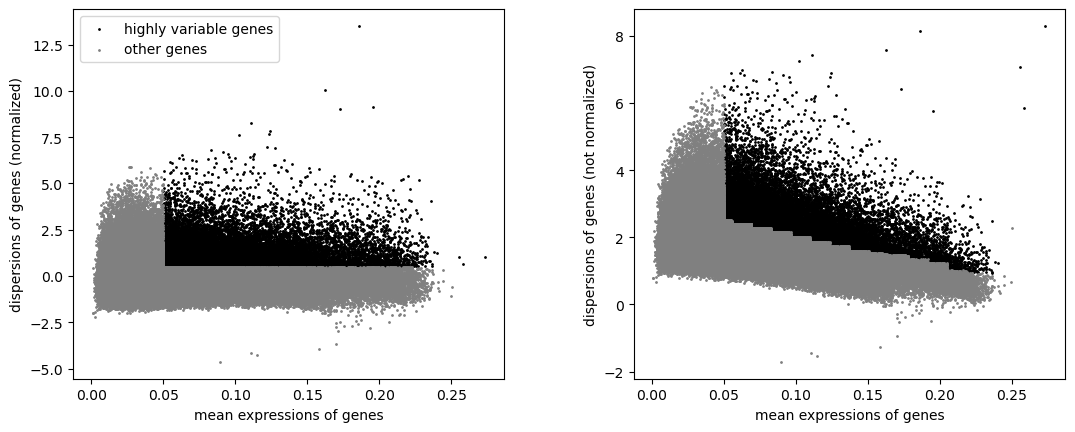

In [80]:
sc.pp.highly_variable_genes(atac_filtered, min_mean=0.05, max_mean=1.5, min_disp=.5)
sc.pl.highly_variable_genes(atac_filtered)

Only keep highly-variable peaks.

In [46]:
# keep_genes = atac_filtered.var["highly_variable"]
# atac_filtered = atac_filtered[:, keep_genes]

In [81]:
np.sum(atac_filtered.var.highly_variable)

np.int64(19121)

### Scaling

For uniformity, and for consequent visualisation, we’ll save log-transformed counts in a .raw slot:

In [82]:
atac_filtered.raw = atac_filtered

## Analysis

After filtering out low-quality cells, normalising the counts matrix, and selecting highly variable peaks, we can already use this data for multimodal integration.

However, as in the case of gene expression, we will study this data individually first and will run PCA on the scaled matrix, compute cell neighbourhood graph, and perform clustering to define cell types. This might be useful later to compare cell type definition between modalities.

### LSI

When working on TF-IDF counts, `sc.tl.pca` or `ac.tl.lsi` can be used to get latent components, e.g.:

In [83]:
ac.tl.lsi(atac_filtered)

We find the first component is typically associated with number of peaks or counts per cell so it is reasonable to remove it:

In [84]:
atac_filtered.obsm['X_lsi'] = atac_filtered.obsm['X_lsi'][:,1:]
atac_filtered.varm["LSI"] = atac_filtered.varm["LSI"][:,1:]
atac_filtered.uns["lsi"]["stdev"] = atac_filtered.uns["lsi"]["stdev"][1:]

The respective neighbourhood graph can be generated with sc.tl.neighbors:

In [85]:
sc.pp.neighbors(atac_filtered, use_rep="X_lsi", n_neighbors=10, n_pcs=30)

### PCA

For this notebook, we are using PCA on the log-normalised counts in atac.X as described above.

In [86]:
sc.pp.scale(atac_filtered)
sc.tl.pca(atac_filtered)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


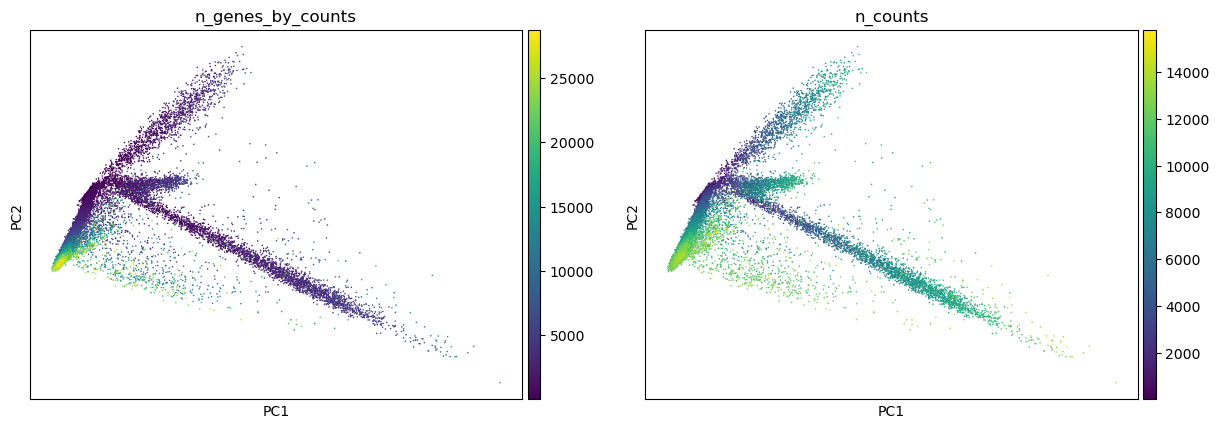

In [87]:
sc.pl.pca(atac_filtered, color=["n_genes_by_counts", "n_counts"])

### Neighbors

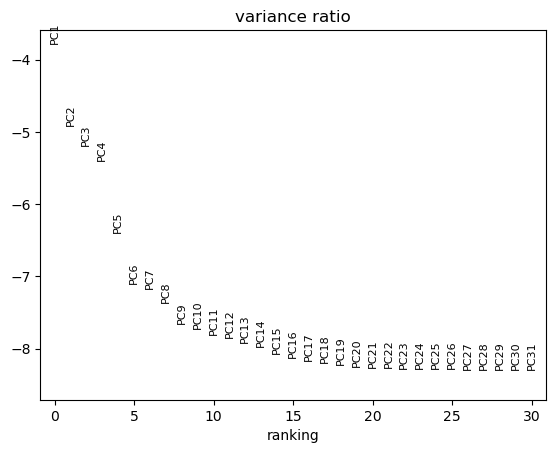

In [88]:
sc.pl.pca_variance_ratio(atac_filtered, log=True)

In [90]:
atac_filtered.obs["donor"] = "mouse_" + atac_filtered.obs_names.str.rsplit("-", n=1).str[1]

In [91]:
# harmony on the trimmed LSI
ho = harmonypy.run_harmony(
    atac_filtered.obsm["X_lsi"].astype(np.float64), atac_filtered.obs, "donor"
)
Z = np.asarray(ho.Z_corr)
if Z.shape[0] != atac_filtered.n_obs:
    Z = Z.T
atac_filtered.obsm["X_lsi_harmony"] = Z

2026-09-15 16:35:14,816 - harmonypy - INFO - Running Harmony
2026-09-15 16:35:14,816 - harmonypy - INFO -   Parameters:
2026-09-15 16:35:14,817 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-15 16:35:14,817 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-15 16:35:14,817 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-15 16:35:14,817 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-15 16:35:14,818 - harmonypy - INFO -     nclust: 100
2026-09-15 16:35:14,818 - harmonypy - INFO -     block_size: 0.05
2026-09-15 16:35:14,819 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-15 16:35:14,819 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-09-15 16:35:14,820 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-15 16:35:14,820 - harmonypy - INFO -     verbose: True
2026-09-15 16:35:14,820 - harmonypy - INFO -     random_state: 0
2026-09-15 16:35:14,820 - harmonypy - INFO -   Data: 49 PCs × 24304 cells
2026-09-15 16:35:14,820 - harmonypy - 

In [99]:
sc.pp.neighbors(atac_filtered, n_neighbors=10, n_pcs=10)

### Non-linear dimensionality reduction and clustering

To stay comparable to the gene expression notebook, we will use leiden to cluster cells. We’ll use UMAP latent space for visualisation below.

In [100]:
sc.tl.umap(atac_filtered, spread=1., min_dist=.5, random_state=11)
sc.tl.leiden(atac_filtered, flavor="igraph", n_iterations=2)

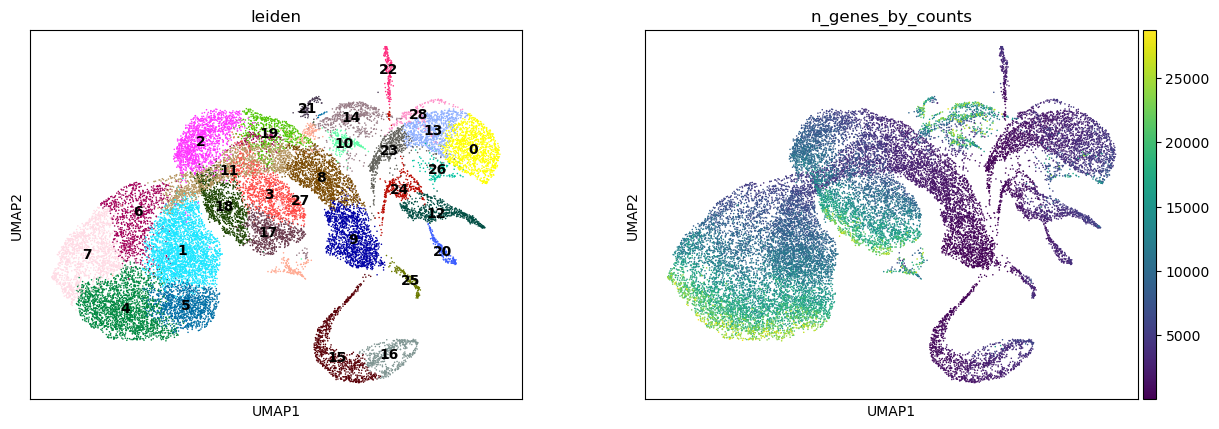

In [101]:
sc.pl.umap(atac_filtered, color=["leiden", "n_genes_by_counts"], legend_loc="on data")

## Saving progress to disk

In [102]:
mu.write(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu/atac"), atac_filtered)

---

# Integrating Gene Expression and Chromatin Accessibility

In this section, we will see how to learn a latent space jointly on two omics.

In [103]:
mdata = mu.read(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu"))
mu.pp.intersect_obs(mdata)
mdata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:

MuData object with n_obs × n_vars = 19691 × 168350
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
  2 modalities
    rna:	19691 x 18960
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'donor', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'celltype_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'tsne', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_tsne', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	19691 x 149390
      obs:	'n_genes_by_counts', 'total_counts', 'outlier', 'n_counts', 'donor', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'umap'
      obsm:	'X_lsi', 'X_lsi_harmony', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

## Perform Integration

We will now run multi-omic factor analysis — a group factor analysis method that will allow us to learn an interpretable latent space jointly on both modalities. Intuitively, it can be viewed as a generalisation of PCA for multi-omics data. More information about this method can be found on the MOFA website.

The time required to train the model depends on the number of cells and features as well as on hardware specs. For the current dataset, it takes 4 minutes on the GeForce RTX 2080 Ti NVIDIA card. Only highly variable features are used by default.

In [104]:
import torch

In [105]:
mu.tl.mofa(
    mdata, 
    outfile=SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}_rna_atac.h5mu",
    gpu_mode=True if torch.cuda.is_available() else False,
    gpu_device=0
    )


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='rna' group='group1' with N=19691 samples and D=3095 features...
Loaded view='atac' group='group1' with N=19691 samples and D=19121 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True


To visualise all the factors together, we’ll use a non-linear dimensionality reduction method such as UMAP to display the embedding in 2D:

In [106]:
sc.pp.neighbors(mdata, use_rep="X_mofa")

In [107]:
sc.tl.umap(mdata, min_dist=.2, spread=1., random_state=10)

Conventional clustering can now be performed based on the MOFA embeddings and also can be visualised on the same UMAP:

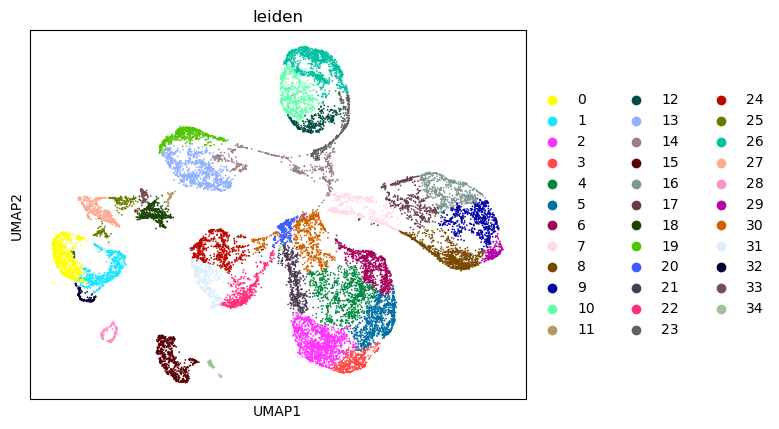

In [108]:
sc.tl.leiden(mdata, flavor="igraph", n_iterations=2)
sc.pl.umap(mdata, color=["leiden"])

## Peak-TG Distance

In [109]:
import pybedtools

MAX_PEAK_DISTANCE = 100_000
TSS_DECAY = 20_000
NEAREST_GENE_ONLY = False


def format_peaks(peak_ids: pd.Index | pd.Series) -> pd.DataFrame:
    """Parse peak IDs such as chr1:100-200 or chr1-100-200."""
    peak_ids = pd.Index(peak_ids).astype(str)
    peak_series = pd.Series(peak_ids, index=peak_ids, name="original_peak_id")

    valid_chr = peak_series.str.contains("chr", regex=False, na=False)
    peak_series = peak_series[valid_chr]

    if peak_series.empty:
        raise ValueError("No peak IDs containing 'chr' were found.")

    parsed = peak_series.str.extract(
        r".*?(?P<chrom>chr[^\s:-]+)(?::|-)(?P<start>\d+)-(?P<end>\d+)\s*$"
    )
    parsed.index = peak_series.index

    missing = parsed[["chrom", "start", "end"]].isna().any(axis=1)
    if missing.any():
        bed_like = peak_series.loc[missing].str.extract(
            r"^\s*(?P<chrom>\S+)\s+(?P<start>\d+)\s+(?P<end>\d+)(?:\s|$)"
        )
        bed_like.index = peak_series.loc[missing].index
        parsed.loc[missing, ["chrom", "start", "end"]] = bed_like[
            ["chrom", "start", "end"]
        ]

    malformed = parsed[["chrom", "start", "end"]].isna().any(axis=1)
    if malformed.any():
        bad = peak_series.loc[malformed].head(3).tolist()
        raise ValueError(f"Malformed peak IDs, e.g. {bad}")

    peak_df = pd.DataFrame(
        {
            "chrom": parsed["chrom"].astype(str),
            "start": pd.to_numeric(parsed["start"]).astype(np.int64),
            "end": pd.to_numeric(parsed["end"]).astype(np.int64),
        },
        index=parsed.index,
    )

    invalid_coordinates = peak_df["end"] <= peak_df["start"]
    if invalid_coordinates.any():
        bad = peak_df.index[invalid_coordinates].tolist()[:3]
        raise ValueError(f"Peaks have end <= start, e.g. {bad}")

    # This preserves the exact ATAC var_name for mapping results back into .var.
    peak_df["peak_id"] = peak_df.index.astype(str)

    return peak_df.reset_index(drop=True)


def find_genes_near_peaks(
    peak_bed: pybedtools.BedTool,
    tss_bed: pybedtools.BedTool,
    distance_cutoff: int,
) -> pd.DataFrame:
    """
    Find peak-TSS pairs within distance_cutoff.

    Assumes tss_bed has four columns:
        chromosome, start, end, gene_id

    Returns one row per (peak, gene) pair, sorted by peak then distance.
    """
    overlaps = peak_bed.window(tss_bed, w=distance_cutoff)

    columns = [
        "peak_chr",
        "peak_start",
        "peak_end",
        "peak_id",
        "gene_chr",
        "gene_start",
        "gene_end",
        "target_id",
    ]

    hits = overlaps.to_dataframe(names=columns, low_memory=False)

    if hits.empty:
        return pd.DataFrame(
            columns=[
                "peak_id",
                "target_id",
                "TSS_dist",
                "TSS_dist_score",
            ]
        )

    numeric_columns = [
        "peak_start",
        "peak_end",
        "gene_start",
        "gene_end",
    ]
    for column in numeric_columns:
        hits[column] = pd.to_numeric(hits[column], errors="coerce")

    hits = hits.dropna(subset=numeric_columns).copy()

    # Distance from the peak interval to the TSS interval:
    #   0 if the TSS overlaps the peak;
    #   otherwise distance to the closest peak boundary.
    hits["TSS_dist"] = np.maximum.reduce(
        [
            hits["gene_start"].to_numpy() - hits["peak_end"].to_numpy(),
            hits["peak_start"].to_numpy() - hits["gene_end"].to_numpy(),
            np.zeros(len(hits)),
        ]
    ).astype(np.int64)

    hits = hits[hits["TSS_dist"] <= distance_cutoff].copy()
    hits["target_id"] = hits["target_id"].astype(str).str.upper()

    hits = hits.sort_values(
        ["peak_id", "TSS_dist", "target_id"],
        kind="stable",
    )

    if NEAREST_GENE_ONLY:
        hits = hits.drop_duplicates("peak_id", keep="first")
    else:
        # The TSS bed is transcript-level, so one gene contributes many TSS
        # entries and a peak can hit the same gene several times at different
        # distances. Under nearest-only this never surfaced, because the
        # drop_duplicates above collapsed it. Keep the closest TSS per
        # (peak, gene) pair so each pair appears exactly once.
        hits = hits.drop_duplicates(["peak_id", "target_id"], keep="first")

    hits["TSS_dist_score"] = np.exp(
        -hits["TSS_dist"] / TSS_DECAY
    )

    return hits


def add_peak_gene_distances(
    mdata,
    tss_bed_file,
    atac_key: str = "atac",
    overwrite: bool = False,
):
    """
    Add peak-gene distance information to mdata[atac_key].

    Adds to .var (one value per peak, its nearest gene, unchanged from before):
        nearest_gene
        TSS_dist
        TSS_dist_score

    Adds to .uns["peak_gene_links"] (every link inside the window):
        genes        unique gene names, sorted
        gene_ptr     CSR-style offsets, length len(genes) + 1
        peak_idx     column position in atac.var_names, for each link
        TSS_dist     distance for each link
        TSS_dist_score

    Links are grouped by gene and sorted by distance within a gene, so the
    peaks for gene g are peak_idx[gene_ptr[g]:gene_ptr[g + 1]], already in the
    order a max_peaks_per_tg cap wants to slice. That replaces a full scan of
    var["nearest_gene"] per gene with a slice.

    Returns the filtered ATAC modality.
    """
    if atac_key not in mdata.mod:
        raise KeyError(
            f"Modality {atac_key!r} was not found. "
            f"Available modalities: {list(mdata.mod.keys())}"
        )

    tss_bed_file = str(tss_bed_file)
    atac = mdata[atac_key]

    output_columns = [
        "nearest_gene",
        "TSS_dist",
        "TSS_dist_score",
    ]
    existing = [column for column in output_columns if column in atac.var.columns]

    if existing and not overwrite:
        raise ValueError(
            f"ATAC .var already contains {existing}. "
            "Use overwrite=True to replace them."
        )

    print(f"ATAC features: {atac.n_vars:,}")
    print(f"TSS annotation: {tss_bed_file}")

    peak_locs = format_peaks(atac.var_names)

    peak_bed = pybedtools.BedTool.from_dataframe(
        peak_locs[["chrom", "start", "end", "peak_id"]]
    )
    tss_bed = pybedtools.BedTool(tss_bed_file)

    links = find_genes_near_peaks(
        peak_bed,
        tss_bed,
        distance_cutoff=MAX_PEAK_DISTANCE,
    )

    if links.empty:
        raise ValueError("No peak-gene links were found inside the window.")

    # Nearest gene per peak: the first row of each peak's block, since
    # find_genes_near_peaks sorted by peak then distance.
    nearest = links.drop_duplicates("peak_id", keep="first").set_index("peak_id")

    atac.var["nearest_gene"] = atac.var_names.map(nearest["target_id"])

    atac.var["TSS_dist"] = pd.array(
        atac.var_names.map(nearest["TSS_dist"]),
        dtype="Int64",
    )

    atac.var["TSS_dist_score"] = atac.var_names.map(
        nearest["TSS_dist_score"]
    ).astype(float)

    # A peak with any link necessarily has a nearest one, so this filter is
    # identical to the nearest-only version and the peak universe is unchanged.
    keep_peaks = atac.var["nearest_gene"].notna().to_numpy()
    atac = atac[:, keep_peaks].copy()

    print(f"Retained {atac.n_vars:,} peaks with a nearby gene")

    # ---- Full link table, indexed against the FILTERED peak order ----
    peak_position = pd.Series(
        np.arange(atac.n_vars, dtype=np.int32),
        index=atac.var_names,
    )

    links = links[links["peak_id"].isin(peak_position.index)].copy()
    links["peak_idx"] = links["peak_id"].map(peak_position).astype(np.int32)

    genes = np.sort(links["target_id"].unique())
    gene_position = pd.Series(np.arange(len(genes), dtype=np.int32), index=genes)
    links["gene_idx"] = links["target_id"].map(gene_position).astype(np.int32)

    # Group by gene, closest peak first, so a per-gene slice is contiguous.
    links = links.sort_values(["gene_idx", "TSS_dist"], kind="stable")

    counts = np.bincount(links["gene_idx"].to_numpy(), minlength=len(genes))
    gene_ptr = np.zeros(len(genes) + 1, dtype=np.int64)
    np.cumsum(counts, out=gene_ptr[1:])

    atac.uns["peak_gene_links"] = {
        "peaks": np.asarray(atac.var_names, dtype=object),
        "genes": np.asarray(genes, dtype=object),
        "gene_ptr": gene_ptr,
        "peak_idx": links["peak_idx"].to_numpy(np.int32),
        "TSS_dist": links["TSS_dist"].to_numpy(np.int32),
        "TSS_dist_score": links["TSS_dist_score"].to_numpy(np.float32),
    }

    atac.uns["peak_gene_distance_params"] = {
        "tss_annotation": tss_bed_file,
        "maximum_distance": MAX_PEAK_DISTANCE,
        "decay": TSS_DECAY,
        "nearest_gene_only": NEAREST_GENE_ONLY,
        "distance_definition": "minimum interval distance between peak and TSS",
    }

    peaks_per_gene = np.diff(gene_ptr)
    print(
        f"Annotated {len(genes):,} genes with {len(links):,} links "
        f"(median {np.median(peaks_per_gene):.0f}, "
        f"mean {peaks_per_gene.mean():.1f}, max {peaks_per_gene.max():,} peaks per gene)"
    )
    print(
        f"Nearest-gene only would have reached "
        f"{atac.var['nearest_gene'].nunique():,} genes"
    )

    return atac


mdata.mod["atac"] = add_peak_gene_distances(
    mdata, tss_bed_file=tss_path, atac_key="atac", overwrite=True
)


ATAC features: 149,390
TSS annotation: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/mm10/mm10_gene_tss.bed
Retained 147,471 peaks with a nearby gene
Annotated 68,060 genes with 1,276,632 links (median 18, mean 18.8, max 130 peaks per gene)
Nearest-gene only would have reached 40,871 genes


## Ranking genes and peaks

In [110]:
mdata["rna"].obs["leiden_joint"] = mdata.obs["leiden"]
mdata["atac"].obs["leiden_joint"] = mdata.obs["leiden"]

In [111]:
print(f"Num cells: {mdata.n_obs}")
print(f"Num genes: {mdata['rna'].n_vars}")
print(f"Num peaks: {mdata['atac'].n_vars}")

Num cells: 19691
Num genes: 18960
Num peaks: 147471


# Save Processed Data

In [112]:
mdata_file = SAMPLE_PROCESSED_DATA_DIR / "multiome_processed.h5mu"

mdata.write(mdata_file)

print(f"Saved MuData object to {mdata_file}")

Saved MuData object to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/liver_sample/multiome_processed.h5mu


<!-- # Create Metacells -->

In [70]:
from scipy import sparse as sp

def plot_W_subset(W, n_cells=200, title=""):
    if sp.issparse(W):
        W_sub = W[:n_cells, :n_cells].toarray()
    else:
        W_sub = np.asarray(W[:n_cells, :n_cells])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        W_sub,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"shrink": 0.5}
    )
    plt.title(title)
    plt.xlabel("Neighbor Cells")
    plt.ylabel("Cells")
    plt.tight_layout()
    plt.show()

In [71]:
# # Base connectivities between cells from the K-NN graph
# W = mdata.obsp["connectivities"].tocsr().astype(np.float32)

# W = W + sp.diags(np.full(W.shape[0], 1, dtype=np.float32), format="csr")

# def row_norm(mat: sp.csr_matrix) -> sp.csr_matrix:
#     row_sum = np.asarray(mat.sum(axis=1)).ravel()
#     row_sum[row_sum == 0] = 1.0
#     inv = sp.diags(1.0 / row_sum, dtype=np.float32)
#     return inv @ mat

# W = row_norm(W)

# HOPS=1

# W_h = W
# for _ in range(1, int(HOPS)):
#     W_h = W_h @ W 
#     W_h = row_norm(W_h)
# W = W_h

# # Final row normalization to make sure rows sum to 1
# W = row_norm(W)

<!-- Blend the expression of each cell with its neighbors based on the multi-hop diffusion mask. -->

In [72]:
# X_rna = sp.csr_matrix(np.asarray(mdata["rna"].X, dtype=np.float32, order="C"))
# X_atac = sp.csr_matrix(np.asarray(mdata["atac"].X, dtype=np.float32, order="C"))

# X_rna_soft = W @ X_rna      # cells × genes
# X_atac_soft = W @ X_atac    # cells × peaks

In [73]:
# from scipy.cluster.hierarchy import linkage, leaves_list
# from sklearn.metrics import pairwise_distances

# subset_size = min(400, mdata.n_obs)

# def order_cells_by_pca(adata, n_cells=200):
#     # use the same subset of cells you visualize
#     X = adata.obsm["X_pca"][:n_cells]

#     # compute distances
#     D = pairwise_distances(X, metric="euclidean")

#     # hierarchical clustering
#     Z = linkage(D, method="average")

#     # leaf order
#     order = leaves_list(Z)

#     return order

# def to_dense_subset(X, n_cells=200, n_features=200):
#     if sp.issparse(X):
#         X = X[:n_cells, :n_features].toarray()
#     else:
#         X = np.asarray(X[:n_cells, :n_features])
#     return X

# order = order_cells_by_pca(mdata["rna"], n_cells=subset_size)

# # choose a subset
# Xr_orig = to_dense_subset(X_rna, n_cells=subset_size, n_features=subset_size)
# Xa_orig = to_dense_subset(X_atac, n_cells=subset_size, n_features=subset_size)
# Xr = to_dense_subset(X_rna_soft, n_cells=subset_size, n_features=subset_size)
# Xa = to_dense_subset(X_atac_soft, n_cells=subset_size, n_features=subset_size)

# Xr_orig = Xr_orig[order]
# Xa_orig = Xa_orig[order]
# Xr = Xr[order]
# Xa = Xa[order]

<!-- Show how the cells cluster by their expression and accessibility profiles before and after diffusion. -->

In [74]:
# from sklearn.decomposition import TruncatedSVD
# def fit_svd_2d(X, n_cells=1000, n_features=1000):
#     if sp.issparse(X):
#         Xsub = X[:n_cells, :n_features]
#     else:
#         Xsub = np.asarray(X[:n_cells, :n_features])
#     svd = TruncatedSVD(n_components=2, random_state=0)
#     coords = svd.fit_transform(Xsub)
#     return coords

# rna_orig_2d = fit_svd_2d(X_rna)
# rna_soft_2d = fit_svd_2d(X_rna_soft)

# atac_orig_2d = fit_svd_2d(X_atac)
# atac_soft_2d = fit_svd_2d(X_atac_soft)

# fig, ax = plt.subplots(2, 2, figsize=(12, 12))

# ax[0,0].scatter(rna_orig_2d[:, 0], rna_orig_2d[:, 1], s=8, alpha=0.7)
# ax[0,0].set_title("Cell Clustering by RNA\n(Original)")
# ax[0,0].set_xlabel("SVD Component 1")
# ax[0,0].set_ylabel("SVD Component 2")
# ax[0,0].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

# ax[0,1].scatter(rna_soft_2d[:, 0], rna_soft_2d[:, 1], s=8, alpha=0.7)
# ax[0,1].set_title("Cell Clustering by RNA\n(K-NN Smoothing)")
# ax[0,1].set_xlabel("SVD Component 1")
# ax[0,1].set_ylabel("SVD Component 2")
# ax[0,1].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

# ax[1,0].scatter(rna_orig_2d[:, 0], rna_orig_2d[:, 1], s=8, alpha=0.7)
# ax[1,0].set_title("Cell Clustering by ATAC\n(Original)")
# ax[1,0].set_xlabel("SVD Component 1")
# ax[1,0].set_ylabel("SVD Component 2")
# ax[1,0].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

# ax[1,1].scatter(rna_soft_2d[:, 0], rna_soft_2d[:, 1], s=8, alpha=0.7)
# ax[1,1].set_title("Cell Clustering by ATAC\n(K-NN Smoothing)")
# ax[1,1].set_xlabel("SVD Component 1")
# ax[1,1].set_ylabel("SVD Component 2")
# ax[1,1].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

# plt.tight_layout()
# plt.show()
# ## Create and save the pseudobulk DataFrames
# def _standardize_symbols_index(
#     df: pd.DataFrame,
#     *,
#     strip_version_suffix: bool = True,
#     uppercase: bool = True,
#     deduplicate: str = "sum",
# ) -> pd.DataFrame:
#     x = df.copy()
#     idx = x.index.astype(str).str.strip()
#     if strip_version_suffix:
#         idx = idx.str.replace(r"\.\d+$", "", regex=True)
#     if uppercase:
#         idx = idx.str.upper()
#     x.index = idx
#     if deduplicate:
#         if deduplicate == "sum":
#             x = x.groupby(level=0).sum()
#         elif deduplicate == "mean":
#             x = x.groupby(level=0).mean()
#         elif deduplicate == "first":
#             x = x[~x.index.duplicated(keep="first")]
#         elif deduplicate in {"max", "min", "median"}:
#             x = getattr(x.groupby(level=0), deduplicate)()
#         else:
#             raise ValueError(f"Unknown deduplicate policy: {deduplicate}")
#     return x

# pseudo_bulk_rna_df = pd.DataFrame(
#     X_rna_soft.T.toarray(),
#     index=mdata["rna"].var_names,
#     columns=mdata["rna"].obs_names,
# ).fillna(0)

# pseudo_bulk_atac_df = pd.DataFrame(
#     X_atac_soft.T.toarray(),
#     index=mdata["atac"].var_names,
#     columns=mdata["atac"].obs_names,
# ).fillna(0)

# pseudo_bulk_rna_df = _standardize_symbols_index(pseudo_bulk_rna_df)
# pseudobulk_rna_file = SAMPLE_PROCESSED_DATA_DIR / "TG_pseudobulk.parquet"
# pseudobulk_atac_file = SAMPLE_PROCESSED_DATA_DIR / "RE_pseudobulk.parquet"

# print(f"Writing to {pseudobulk_rna_file} and {pseudobulk_atac_file}...")

# pseudo_bulk_rna_df.to_parquet(pseudobulk_rna_file, engine="pyarrow", compression="snappy")
# pseudo_bulk_atac_df.to_parquet(pseudobulk_atac_file, engine="pyarrow", compression="snappy")
    

In [75]:
# print(f"Num Genes: {pseudo_bulk_rna_df.shape[0]}")
# print(f"Num Peaks: {pseudo_bulk_atac_df.shape[0]}")
# print(f"Num Metacells: {pseudo_bulk_rna_df.shape[1]}")

